In [ ]:
import numpy as np
# Base
vm = [0.0495, 0.0578, 0.0567, 0.0547, 0.0629, 0.0598, 0.0534, 0.0528, 0.0603, 0.0552]
ss = [0.0394, 0.0376, 0.0514, 0.0437, 0.0470, 0.0438, 0.0383, 0.0395, 0.0490, 0.0323]
tr = [0.0428, 0.0493, 0.0564, 0.0489, 0.0537, 0.0566, 0.0478, 0.0437, 0.0545, 0.0464]

np.mean(vm), np.std(vm), np.mean(ss), np.std(ss), np.mean(tr), np.std(tr)

In [ ]:
# Mix (Normal + VMess)
ss = [0.5702, 0.4969, 0.4458, 0.5385, 0.5164, 0.5245, 0.4820, 0.4611, 0.5379, 0.5056, 0.5449]
tr = [0.5123, 0.4654, 0.4613, 0.5264, 0.4983, 0.5045, 0.4606, 0.5105, 0.4688, 0.5026, 0.5029]

np.mean(ss), np.std(ss), np.mean(tr), np.std(tr)

(0.03587152234994328, 0.022439468622632654)

In [ ]:
# Mix + Strip
ss = [0.5648, 0.538, 0.5618, 0.4961, 0.551, 0.4809, 0.5524, 0.5149, 0.4763, 0.493]
tr = [0.5676, 0.5983, 0.603, 0.5884, 0.586, 0.532, 0.6095, 0.5795, 0.5649, 0.5786]

np.mean(ss), np.std(ss), np.mean(tr), np.std(tr)

In [ ]:
# Mix + Strip + Size Filter
ss = [0.7547, 0.7472, 0.7643, 0.7539, 0.7466, 0.7588, 0.7433, 0.7522, 0.7723, 0.7516]
tr = [0.6564, 0.6112, 0.6189, 0.6532, 0.6604, 0.6547, 0.6391, 0.6447, 0.6552, 0.6359]

np.mean(ss), np.mean(tr)
np.std(ss), np.std(tr)

In [ ]:
# Mix (Normal + Shadowsocks)
vm = [0.3969, 0.4311, 0.4259, 0.4417, 0.4260, 0.4324, 0.4537, 0.4309, 0.4964, 0.416]
tr = [0.4458, 0.4348, 0.4362, 0.4555, 0.4509, 0.4563, 0.4245, 0.4239, 0.4555, 0.4326]


np.mean(vm), np.std(vm), np.mean(tr), np.std(tr)

In [ ]:
# Mix + Strip
vm = [0.444, 0.446, 0.452, 0.479, 0.448, 0.455, 0.482, 0.491, 0.450, 0.426]
tr = [0.478, 0.480, 0.485, 0.497, 0.475, 0.482, 0.481, 0.508, 0.512, 0.472]


np.mean(vm), np.std(vm), np.mean(tr), np.std(tr)

In [ ]:
# Mix + Strip + Size Filter

vm = [0.7391, 0.7259, 0.7146, 0.7390, 0.7395, 0.7293, 0.7416, 0.7395, 0.7311, 0.7525]
tr = [0.5698, 0.5675, 0.6004, 0.5571, 0.5736, 0.5911, 0.5755, 0.5744, 0.5938, 0.5604]

np.mean(vm), np.std(vm), np.mean(tr), np.std(tr)

In [ ]:
# Mix (Normal + Trojan)

vm = [0.5269, 0.5389, 0.5472, 0.5113, 0.5442, 0.4992, 0.5325, 0.5214, 0.5313, 0.5199]
ss = [0.5977, 0.6556, 0.6274, 0.5943, 0.6208, 0.6056, 0.6168, 0.6516, 0.6241, 0.6353]

np.mean(vm), np.std(vm), np.mean(ss), np.std(ss)

In [ ]:
# Mix + Strip (Normal + Trojan)

vm = [0.5951, 0.5763, 0.6153, 0.603, 0.5711, 0.6047, 0.5865, 0.6004, 0.5937, 0.5756, ]
ss = [0.6877, 0.6636, 0.6494, 0.6616, 0.6659, 0.6659, 0.6498, 0.6338, 0.6479, 0.6481]

np.mean(vm), np.std(vm), np.mean(ss), np.std(ss)

In [ ]:
# Mix + Strip + Size Filter

vm = [0.6876, 0.6556, 0.6815, 0.6846, 0.6881, 0.7034, 0.7071, 0.6908, 0.6757, 0.6894]
ss = [0.7402, 0.7208, 0.7112, 0.7253, 0.7116, 0.7573, 0.7557, 0.7376, 0.734, 0.7509]

np.mean(vm), np.std(vm), np.mean(ss), np.std(ss)

In [2]:
import json
import re
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd

WORKSPACE = Path("/data/exp/lxyu/Dataset/WF/Reproduce/workspace")

# Or discover many files at once, e.g.:
# file_paths = sorted(WORKSPACE.glob("vmess_*_DF.json"))

ALL_PROTOCOLS = ("vmess", "shadowsocks", "trojan")
# Test order matches scripts/*_test.sh calls for each training protocol
TEST_PROTOCOL_ORDER = {
    "vmess": ("shadowsocks", "trojan"),
    "shadowsocks": ("vmess", "trojan"),
    "trojan": ("vmess", "shadowsocks"),
}
PROTOCOL_LABELS = {p: p.capitalize() for p in ALL_PROTOCOLS}

def parse_f1_scores(file_path: Path) -> list[float]:
    with open(file_path, "r") as f:
        content = f.read()
    json_objects = re.findall(r"\{.*?\}", content, re.DOTALL)
    f1_scores = []
    for obj_str in json_objects:
        try:
            data = json.loads(obj_str)
            score = data.get("F1-score")
            if score is not None:
                f1_scores.append(score)
        except json.JSONDecodeError:
            print(f"Invalid JSON object skipped in {file_path.name}.")
    return f1_scores


def infer_train_protocol(stem: str) -> Optional[str]:
    for protocol in ALL_PROTOCOLS:
        if stem == protocol or stem.startswith(f"{protocol}_"):
            return protocol
    return None


def format_mean_std(values, decimals: int = 3) -> str:
    return (
        f"{np.round(np.mean(values), decimals):.3f} "
        f"($\\pm {np.round(np.std(values), decimals):.3f}$)"
    )


def build_f1_table(file_paths, decimals: int = 3) -> pd.DataFrame:
    rows = []
    column_order = []

    for file_path in file_paths:
        file_path = Path(file_path)
        if not file_path.exists():
            continue
        stem = file_path.stem
        train_protocol = infer_train_protocol(stem)
        if train_protocol is None:
            raise ValueError(f"Cannot infer training protocol from filename: {stem}")

        test_protocols = TEST_PROTOCOL_ORDER[train_protocol]
        f1_scores = parse_f1_scores(file_path)
        n_protocols = len(test_protocols)
        if len(f1_scores) % n_protocols != 0:
            raise ValueError(
                f"{stem}: expected F1 count divisible by {n_protocols}, got {len(f1_scores)}"
            )

        row = {"file": stem}
        for i, protocol in enumerate(test_protocols):
            label = PROTOCOL_LABELS[protocol]
            protocol_scores = f1_scores[i::n_protocols]
            row[label] = format_mean_std(protocol_scores, decimals)
            if label not in column_order:
                column_order.append(label)
        rows.append(row)

    df = pd.DataFrame(rows).set_index("file")
    return df

def build_paths(model, train_protocol, feature_type):
    files = [
        f"{train_protocol}_{feature_type}_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_4_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_strip_4_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_strip_4_aug_slope_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_strip_4_aug_known_slope_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_strip_4_aug_noproxy_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_strip_4_aug_no_cdf_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_strip_4_aug_cdf_{model}",
        f"{train_protocol}_{feature_type}_bs_filter_strip_4_aug_slope_gaussian_{model}",
    ]
    file_paths = [
        WORKSPACE / f"{file}.json" for file in files
    ]

    return file_paths


In [3]:
model = "DF"
train_protocol = "shadowsocks"
feature_type = "size_bin"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Vmess,Trojan
file,,
shadowsocks_size_bin_DF,0.481 ($\pm 0.010$),0.473 ($\pm 0.019$)
shadowsocks_size_bin_bs_filter_4_DF,0.540 ($\pm 0.016$),0.522 ($\pm 0.016$)
shadowsocks_size_bin_bs_filter_strip_4_DF,0.565 ($\pm 0.011$),0.570 ($\pm 0.009$)
shadowsocks_size_bin_bs_filter_strip_4_aug_slope_gaussian_DF,0.611 ($\pm 0.007$),0.591 ($\pm 0.011$)


In [5]:
model = "DF"
train_protocol = "trojan"
feature_type = "size_bin"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Vmess,Shadowsocks
file,,
trojan_size_bin_DF,0.487 ($\pm 0.011$),0.569 ($\pm 0.013$)
trojan_size_bin_bs_filter_4_DF,0.502 ($\pm 0.023$),0.553 ($\pm 0.022$)
trojan_size_bin_bs_filter_strip_4_DF,0.513 ($\pm 0.022$),0.573 ($\pm 0.025$)
trojan_size_bin_bs_filter_strip_4_aug_slope_gaussian_DF,0.606 ($\pm 0.012$),0.692 ($\pm 0.030$)


In [15]:
model = "DF"
train_protocol = "vmess"
feature_type = "size_bin"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Shadowsocks,Trojan
file,,
vmess_size_bin_DF,0.523 ($\pm 0.031$),0.480 ($\pm 0.021$)
vmess_size_bin_bs_filter_4_DF,0.654 ($\pm 0.019$),0.548 ($\pm 0.014$)
vmess_size_bin_bs_filter_strip_4_DF,0.676 ($\pm 0.020$),0.609 ($\pm 0.010$)
vmess_size_bin_bs_filter_strip_4_aug_slope_DF,0.744 ($\pm 0.007$),0.605 ($\pm 0.012$)
vmess_size_bin_bs_filter_strip_4_aug_known_slope_DF,0.736 ($\pm 0.008$),0.611 ($\pm 0.019$)
vmess_size_bin_bs_filter_strip_4_aug_noproxy_DF,0.752 ($\pm 0.008$),0.628 ($\pm 0.017$)
vmess_size_bin_bs_filter_strip_4_aug_no_cdf_DF,0.710 ($\pm 0.016$),0.637 ($\pm 0.010$)
vmess_size_bin_bs_filter_strip_4_aug_cdf_DF,0.724 ($\pm 0.009$),0.641 ($\pm 0.009$)
vmess_size_bin_bs_filter_strip_4_aug_slope_gaussian_DF,0.763 ($\pm 0.016$),0.612 ($\pm 0.006$)


In [16]:
model = "BAPM"
train_protocol = "vmess"
feature_type = "size_bin"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Shadowsocks,Trojan
file,,
vmess_size_bin_BAPM,0.376 ($\pm 0.011$),0.422 ($\pm 0.008$)
vmess_size_bin_bs_filter_4_BAPM,0.511 ($\pm 0.006$),0.491 ($\pm 0.005$)
vmess_size_bin_bs_filter_strip_4_BAPM,0.545 ($\pm 0.003$),0.538 ($\pm 0.002$)
vmess_size_bin_bs_filter_strip_4_aug_slope_BAPM,0.618 ($\pm 0.005$),0.579 ($\pm 0.005$)
vmess_size_bin_bs_filter_strip_4_aug_known_slope_BAPM,0.615 ($\pm 0.009$),0.558 ($\pm 0.008$)
vmess_size_bin_bs_filter_strip_4_aug_noproxy_BAPM,0.526 ($\pm 0.019$),0.554 ($\pm 0.007$)
vmess_size_bin_bs_filter_strip_4_aug_no_cdf_BAPM,0.539 ($\pm 0.012$),0.562 ($\pm 0.009$)
vmess_size_bin_bs_filter_strip_4_aug_cdf_BAPM,0.527 ($\pm 0.011$),0.545 ($\pm 0.006$)
vmess_size_bin_bs_filter_strip_4_aug_slope_gaussian_BAPM,0.636 ($\pm 0.006$),0.587 ($\pm 0.007$)


In [17]:
model = "TF"
train_protocol = "vmess"
feature_type = "size_bin"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Shadowsocks,Trojan
file,,
vmess_size_bin_TF,0.908 ($\pm 0.004$),0.873 ($\pm 0.004$)
vmess_size_bin_bs_filter_4_TF,0.927 ($\pm 0.002$),0.891 ($\pm 0.001$)
vmess_size_bin_bs_filter_strip_4_TF,0.935 ($\pm 0.004$),0.904 ($\pm 0.002$)
vmess_size_bin_bs_filter_strip_4_aug_slope_TF,0.963 ($\pm 0.002$),0.926 ($\pm 0.004$)
vmess_size_bin_bs_filter_strip_4_aug_known_slope_TF,0.964 ($\pm 0.002$),0.927 ($\pm 0.003$)
vmess_size_bin_bs_filter_strip_4_aug_noproxy_TF,0.958 ($\pm 0.002$),0.918 ($\pm 0.002$)
vmess_size_bin_bs_filter_strip_4_aug_no_cdf_TF,0.954 ($\pm 0.002$),0.924 ($\pm 0.002$)
vmess_size_bin_bs_filter_strip_4_aug_cdf_TF,0.956 ($\pm 0.002$),0.922 ($\pm 0.004$)
vmess_size_bin_bs_filter_strip_4_aug_slope_gaussian_TF,0.966 ($\pm 0.001$),0.926 ($\pm 0.001$)


In [18]:
model = "NetCLR"
train_protocol = "vmess"
feature_type = "size_bin"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Shadowsocks,Trojan
file,,
vmess_size_bin_NetCLR,0.402 ($\pm 0.013$),0.406 ($\pm 0.008$)
vmess_size_bin_bs_filter_4_NetCLR,0.519 ($\pm 0.016$),0.474 ($\pm 0.010$)
vmess_size_bin_bs_filter_strip_4_NetCLR,0.571 ($\pm 0.006$),0.492 ($\pm 0.003$)
vmess_size_bin_bs_filter_strip_4_aug_slope_NetCLR,0.709 ($\pm 0.014$),0.554 ($\pm 0.018$)
vmess_size_bin_bs_filter_strip_4_aug_known_slope_NetCLR,0.703 ($\pm 0.009$),0.557 ($\pm 0.014$)
vmess_size_bin_bs_filter_strip_4_aug_noproxy_NetCLR,0.705 ($\pm 0.016$),0.584 ($\pm 0.005$)
vmess_size_bin_bs_filter_strip_4_aug_no_cdf_NetCLR,0.664 ($\pm 0.013$),0.562 ($\pm 0.006$)
vmess_size_bin_bs_filter_strip_4_aug_cdf_NetCLR,0.673 ($\pm 0.013$),0.563 ($\pm 0.007$)
vmess_size_bin_bs_filter_strip_4_aug_slope_gaussian_NetCLR,0.734 ($\pm 0.016$),0.569 ($\pm 0.014$)


In [19]:
model = "TikTok"
train_protocol = "vmess"
feature_type = "dt"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Shadowsocks,Trojan
file,,
vmess_dt_TikTok,0.877 ($\pm 0.003$),0.783 ($\pm 0.005$)
vmess_dt_bs_filter_4_TikTok,0.885 ($\pm 0.003$),0.824 ($\pm 0.006$)
vmess_dt_bs_filter_strip_4_TikTok,0.886 ($\pm 0.004$),0.820 ($\pm 0.004$)
vmess_dt_bs_filter_strip_4_aug_slope_TikTok,0.922 ($\pm 0.002$),0.836 ($\pm 0.006$)
vmess_dt_bs_filter_strip_4_aug_known_slope_TikTok,0.922 ($\pm 0.004$),0.829 ($\pm 0.005$)
vmess_dt_bs_filter_strip_4_aug_noproxy_TikTok,0.902 ($\pm 0.005$),0.829 ($\pm 0.007$)
vmess_dt_bs_filter_strip_4_aug_no_cdf_TikTok,0.899 ($\pm 0.004$),0.830 ($\pm 0.004$)
vmess_dt_bs_filter_strip_4_aug_cdf_TikTok,0.902 ($\pm 0.006$),0.831 ($\pm 0.006$)
vmess_dt_bs_filter_strip_4_aug_slope_gaussian_TikTok,0.932 ($\pm 0.002$),0.837 ($\pm 0.005$)


In [20]:
model = "RF"
train_protocol = "vmess"
feature_type = "tsam"
file_paths = build_paths(model, train_protocol, feature_type)
df = build_f1_table(file_paths)
display(df)

,Shadowsocks,Trojan
file,,
vmess_tsam_RF,0.635 ($\pm 0.008$),0.596 ($\pm 0.019$)
vmess_tsam_bs_filter_4_RF,0.684 ($\pm 0.008$),0.634 ($\pm 0.009$)
vmess_tsam_bs_filter_strip_4_RF,0.686 ($\pm 0.006$),0.639 ($\pm 0.012$)
vmess_tsam_bs_filter_strip_4_aug_slope_RF,0.759 ($\pm 0.009$),0.700 ($\pm 0.009$)
vmess_tsam_bs_filter_strip_4_aug_known_slope_RF,0.755 ($\pm 0.004$),0.699 ($\pm 0.007$)
vmess_tsam_bs_filter_strip_4_aug_noproxy_RF,0.706 ($\pm 0.048$),0.641 ($\pm 0.050$)
vmess_tsam_bs_filter_strip_4_aug_no_cdf_RF,0.693 ($\pm 0.009$),0.650 ($\pm 0.013$)
vmess_tsam_bs_filter_strip_4_aug_cdf_RF,0.697 ($\pm 0.010$),0.664 ($\pm 0.012$)
vmess_tsam_bs_filter_strip_4_aug_slope_gaussian_RF,0.766 ($\pm 0.007$),0.701 ($\pm 0.004$)


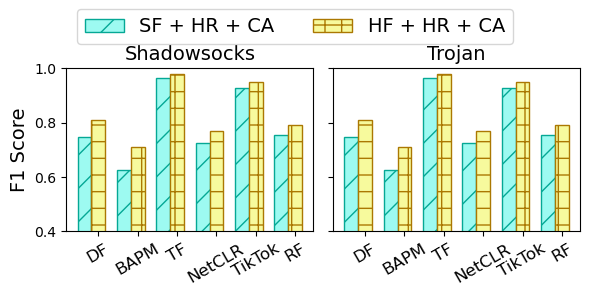

In [9]:
import numpy as np
import matplotlib.pyplot as plt

models = ['DF', 'BAPM', 'TF', 'NetCLR', 'TikTok', 'RF']
methods = ['SF + HR + CA', 'HF + HR + CA']
protocols = ['Shadowsocks', 'Trojan']

# Organize F1 scores into matrices: shape [n_methods, n_models]
shadowsocks_data = np.array([
    # [0.53, 0.340, 0.914, 0.414, 0.873, 0.584],
    # [0.666, 0.506, 0.929, 0.584, 0.888, 0.691],
    # [0.694, 0.528, 0.939, 0.657, 0.891, 0.694],
    [0.749, 0.626, 0.964, 0.727, 0.927, 0.754],
    [0.808, 0.712, 0.980, 0.771, 0.951, 0.792]
])
trojan_data = np.array([
    # [0.485, 0.420, 0.872, 0.417, 0.774, 0.504],
    # [0.559, 0.493, 0.883, 0.519, 0.817, 0.633],
    # [0.623, 0.541, 0.898, 0.553, 0.818, 0.639],
    [0.660, 0.583, 0.930, 0.608, 0.830, 0.649],
    [0.809, 0.759, 0.981, 0.775, 0.952, 0.779]
])

bar_width = 0.35
x = np.arange(len(models))  # the label locations

fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

edgecolor = ['#05a895', '#ab7802', '#4c03a6', '#0316a6', '#a60319', '#c8d604']
hatch = ['/', '+', 'o', '*', 'x', '|']
color = ['#9dfaf1', '#f7fa9d', '#d4b3fc', '#9ea9ff', '#fc95a3', '#f7fca9']

# Plot for Shadowsocks
for i in range(len(methods)):
    axs[0].bar(x + i*bar_width - 1*bar_width, shadowsocks_data[i], width=bar_width, label=methods[i], edgecolor=edgecolor[i], hatch=hatch[i], color=color[i])
axs[0].set_xticks(x)
axs[0].set_xticklabels(models, fontsize=12, rotation=30)
axs[0].set_title('Shadowsocks', fontsize=14)
# axs[0].set_xlabel('Model', fontsize=14)
axs[0].set_ylabel('F1 Score', fontsize=14)
axs[0].set_ylim(0.4, 1)

# Plot for Trojan
for i in range(len(methods)):
    axs[1].bar(x + i*bar_width - 1*bar_width, shadowsocks_data[i], width=bar_width, label=methods[i], edgecolor=edgecolor[i], hatch=hatch[i], color=color[i])
axs[1].set_xticks(x)
axs[1].set_xticklabels(models, fontsize=12, rotation=30)
axs[1].set_title('Trojan', fontsize=14)
# axs[1].set_xlabel('Model', fontsize=14)
axs[1].set_ylim(0.4, 1)

# Create a single legend at the top center
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(methods), fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.9])  # leaves space for legend
fig.savefig("host_filter.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

In [1]:
import numpy as np
import seaborn
import matplotlib.pyplot as plt
from pathlib import Path

def plot_f1_heatmap(
    f1_matrix: np.ndarray,
    output_file: str,
    title: str = "F1-Score Heatmap",
    cmap: str = "RdYlBu_r",
    figsize: tuple = (8, 6),
    annot_fmt: str = ".2f"
) -> None:
    output_path = Path(output_file)
    filename = output_path.stem
    # Set up figure
    plt.figure(figsize=figsize)
    
    # Create heatmap without NoProxy rows/columns, control annotation font size
    # Added param: cbar_tick_fontsize to control colorbar tick fontsize
    sns_heatmap = seaborn.heatmap(
        f1_matrix,
        annot=True,  # Show values on cells
        fmt=annot_fmt,  # Format for annotations
        cmap=cmap,  # Colormap
        vmin=0,  # Color bar minimum
        vmax=1,  # Color bar maximum
        # cbar_kws={"label": "F1-Score"},  # Color bar label and font size
        square=False,  # Non-square cells for clarity
        xticklabels=['VMess', 'Shadowsocks', 'Trojan'],
        yticklabels=['VMess', 'Shadowsocks', 'Trojan'],
        annot_kws={"fontsize": 18},  # Control the font size of value annotation
    )
    # Enlarge tick label font sizes
    sns_heatmap.set_xticklabels(sns_heatmap.get_xticklabels(), fontsize=16)
    sns_heatmap.set_yticklabels(sns_heatmap.get_yticklabels(), fontsize=16)
    # Move x-tick labels to the top
    sns_heatmap.xaxis.set_ticks_position('top')
    sns_heatmap.xaxis.set_label_position('top')
    plt.xticks(rotation=0)  # Optional: keep x-tick labels horizontal

    # --- Colorbar tick fontsize control ---
    # Get cbar_tick_fontsize from the function args, set default if not there
    cbar_tick_fontsize = locals().get('cbar_tick_fontsize', 14)
    colorbar = sns_heatmap.collections[0].colorbar
    if colorbar is not None:
        colorbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    # Set title and labels
    # plt.suptitle(title, y=0.08, fontsize=14)
    plt.xlabel("Protocol in Testing Dataset", fontsize=18)
    plt.ylabel("Protocol in Training Dataset", fontsize=18)
    
    # Save figure
    plt.savefig(output_path, dpi=300, bbox_inches="tight", format='pdf')
    
    # Close to free memory
    plt.close()

# The original full matrix with NoProxy (for backup)
# F1_score = np.array([[0.996, 0.053, 0.049, 0.050],
#                      [0.082, 0.987, 0.497, 0.464],
#                      [0.081, 0.426, 0.989, 0.418],
#                      [0.068, 0.490, 0.558, 0.979]])

# Remove NoProxy row and column (first row/col)
F1_score = np.array([
    [0.987, 0.523, 0.480],
    [0.481, 0.989, 0.473],
    [0.487, 0.569, 0.979]
])
        

plot_f1_heatmap(F1_score, "perf_degrade.pdf")